<a href="https://colab.research.google.com/github/Tilly-11/Quantitative-finance-projects/blob/main/macro_stress_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [4]:
def fetch_stress_data(tickers, start_date='2007-01-01', end_date='2024-01-01'):
    """
    Downloads 17 years of historical data for assets and the S&P 500 (^GSPC).
    Calculates stationary daily returns and cleans up missing data.
    """
    # Append S&P 500 (^GSPC) as a market proxy for historical gaps (like TSLA in 2008)
    all_symbols = tickers + ['^GSPC']
    raw_data = yf.download(all_symbols, start=start_date, end=end_date)

    df = raw_data['Close']
    if df.isnull().values.any():
        df = df.fillna(method='ffill').fillna(method='bfill')

    returns = df.pct_change().dropna()
    return returns

In [5]:
def run_scenario_analysis(returns, weights, portfolio_value, tickers):
    """
    Isolates specific historical macroeconomic shocks and calculates
    the exact single-day portfolio impact for each scenario.
    """
    weights_array = np.array(weights)
    scenarios = {}

    # Scenario 1: The 2008 Lehman Brothers Collapse (Sep 29, 2008)
    # Because TSLA didn't exist, we map its performance to the market proxy (^GSPC) for this day
    lehman_date = '2008-09-29'
    if lehman_date in returns.index:
        lehman_returns = []
        for t in tickers:
            if t in returns.columns:
                lehman_returns.append(returns.loc[lehman_date, t])
            else:
                lehman_returns.append(returns.loc[lehman_date, '^GSPC']) # Use Proxy

        portfolio_lehman_ret = np.dot(lehman_returns, weights_array)
        scenarios['2008 Lehman Crash'] = portfolio_lehman_ret

    # Scenario 2: The 2020 COVID-19 Liquidity Shock (March 16, 2020)
    # Black Monday 2020: A severe systemic market crash where all assets collapsed simultaneously
    covid_date = '2020-03-16'
    if covid_date in returns.index:
        covid_returns = [returns.loc[covid_date, t] for t in tickers]
        portfolio_covid_ret = np.dot(covid_returns, weights_array)
        scenarios['2020 COVID Shock'] = portfolio_covid_ret

    # Scenario 3: Custom Tech Meltdown (Hypothetical Stress Test)
    # We simulate a modern sector crisis: a synchronized -8% drop in tech, and a severe -15% drop for high-beta TSLA
    tech_meltdown_returns = []
    for t in tickers:
        if t == 'TSLA':
            tech_meltdown_returns.append(-0.15) # High volatility asset penalty
        else:
            tech_meltdown_returns.append(-0.08) # Standard tech sector penalty

    portfolio_tech_ret = np.dot(tech_meltdown_returns, weights_array)
    scenarios['Tech Sector Meltdown'] = portfolio_tech_ret

    # Calculate absolute dollar impacts
    dollar_impacts = {k: v * portfolio_value for k, v in scenarios.items()}

    return scenarios, dollar_impacts

In [6]:
def plot_stress_results(scenarios, dollar_impacts, output_filename='portfolio_stress_test.png'):
    """
    Generates and saves an institutional-grade bar chart comparing
    the financial damage across different stress scenarios.
    """
    labels = list(scenarios.keys())
    pct_losses = [v * 100 for v in scenarios.values()]
    cash_losses = list(dollar_impacts.values())

    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels, pct_losses, color=['#d9534f', '#f0ad4e', '#5bc0de'], edgecolor='black', alpha=0.85)

    # Add data labels on top of the bars showing both % and $ losses
    for bar, pct, cash in zip(bars, pct_losses, cash_losses):
        yval = bar.get_height()
        # Places text slightly above or below the bar depending on height direction
        plt.text(bar.get_x() + bar.get_width()/2.0, yval - 1.2, f"{pct:.2f}%\n(${cash:,.2f})",
                 ha='center', va='center', fontweight='bold', color='white', fontsize=10)

    plt.ylabel('Portfolio Impact / Return (%)', fontsize=12)
    plt.title('Macroeconomic Stress Testing & Scenario Analysis', fontsize=14, fontweight='bold')
    plt.axhline(0, color='black', linewidth=1) # Baseline zero line
    plt.grid(axis='y', alpha=0.2)

    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_554/3306201230.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(all_symbols, start=start_date, end=end_date)
[*********************100%***********************]  6 of 6 completed
/tmp/ipykernel_554/3306201230.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')



--- Macro-Economic Stress Testing Executive Summary ---

Scenario: [2008 Lehman Crash]
 -> Projected Capital Drawdown: -9.73%
 -> Impact on $100k Liquidity: $-9,729.46

Scenario: [2020 COVID Shock]
 -> Projected Capital Drawdown: -12.64%
 -> Impact on $100k Liquidity: $-12,637.08

Scenario: [Tech Sector Meltdown]
 -> Projected Capital Drawdown: -9.40%
 -> Impact on $100k Liquidity: $-9,400.00


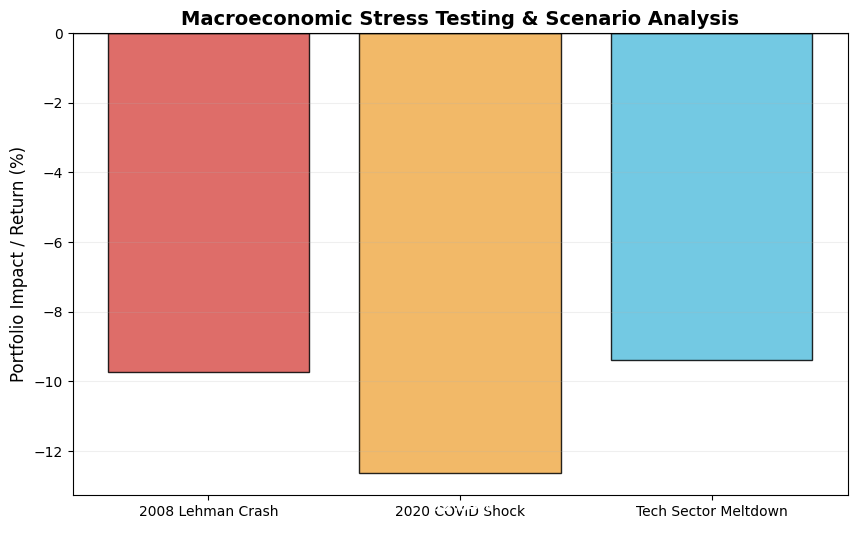

In [7]:
#Define configuration settings
target_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
allocation_weights = [0.2, 0.2, 0.2, 0.2, 0.2] # 20% in each asset
liquidity_budget = 100000 # $100,000 USD capital

#Run the pipeline functions
historical_master_returns = fetch_stress_data(target_tickers)

percentage_shocks, dollar_shocks = run_scenario_analysis(
    returns=historical_master_returns,
    weights=allocation_weights,
    portfolio_value=liquidity_budget,
    tickers=target_tickers
)

#Print a summary report for the Risk Team
print("\n--- Macro-Economic Stress Testing Executive Summary ---")
for scenario in percentage_shocks.keys():
    print(f"\nScenario: [{scenario}]")
    print(f" -> Projected Capital Drawdown: {percentage_shocks[scenario] * 100:.2f}%")
    print(f" -> Impact on $100k Liquidity: ${dollar_shocks[scenario]:,.2f}")

# 4. Render and save the institutional report graph
plot_stress_results(percentage_shocks, dollar_shocks)